# SynthACticBench O1: 1,500-trial leaf policies

Problem seed 53, `min_samples_split=1`, and five SMAC seeds. The staged policy uses leaf size 3 for trials 1–500, leaf size 2 for trials 501–1,000, and leaf size 1 for trials 1,001–1,500.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/leaf_policies/06_1500_iterations_different_seed")
OUTPUT_DIRECTORY = HERE / "smac_output"
POLICIES = ("fixed_leaf_1", "fixed_leaf_2", "fixed_leaf_3", "fixed_leaf_4", "fixed_leaf_5", "staged_leaf_3_2_1")
SEEDS = tuple(range(5))
N_TRIALS = 1500
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {
    "fixed_leaf_1": "fixed leaf = 1",
    "fixed_leaf_2": "fixed leaf = 2",
    "fixed_leaf_3": "fixed leaf = 3",
    "fixed_leaf_4": "fixed leaf = 4",
    "fixed_leaf_5": "fixed leaf = 5",
    "staged_leaf_3_2_1": "staged 3 → 2 → 1",
}

In [2]:
def load_results(policy):
    by_seed = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        seed = result["smac_seed"]
        if seed in SEEDS and result["n_trials"] == N_TRIALS:
            if seed not in by_seed or path.stat().st_mtime > by_seed[seed][0]:
                by_seed[seed] = (path.stat().st_mtime, result)
    missing = sorted(set(SEEDS) - set(by_seed))
    if missing:
        raise FileNotFoundError(f"Missing completed runs for {policy}, seeds={missing}")
    return {seed: by_seed[seed][1] for seed in SEEDS}


results = {policy: load_results(policy) for policy in POLICIES}
for runs in results.values():
    for result in runs.values():
        assert result["problem_seed"] == 52
        assert result["min_samples_split"] == 1
        assert result["n_trials"] == N_TRIALS
        assert min(result["regret"]) >= -1e-8
for seed in SEEDS:
    staged = results["staged_leaf_3_2_1"][seed]
    assert staged["stage_boundaries"] == [500, 1000]
    assert staged["objective_value"][:500] == results["fixed_leaf_3"][seed]["objective_value"][:500]
print(f"Loaded {sum(len(runs) for runs in results.values())}/{len(POLICIES) * len(SEEDS)} validated trajectories.")
print("Known global minimum:", results["fixed_leaf_1"][0]["f_min"])
print("Staged transitions:")
for seed in SEEDS:
    print(seed, results["staged_leaf_3_2_1"][seed]["transitions"])

Loaded 30/30 validated trajectories.
Known global minimum: -334610.3514164455
Staged transitions:
0 [[0, 3], [500, 2], [1000, 1]]
1 [[0, 3], [500, 2], [1000, 1]]
2 [[0, 3], [500, 2], [1000, 1]]
3 [[0, 3], [505, 2], [1000, 1]]
4 [[0, 3], [500, 2], [1000, 1]]


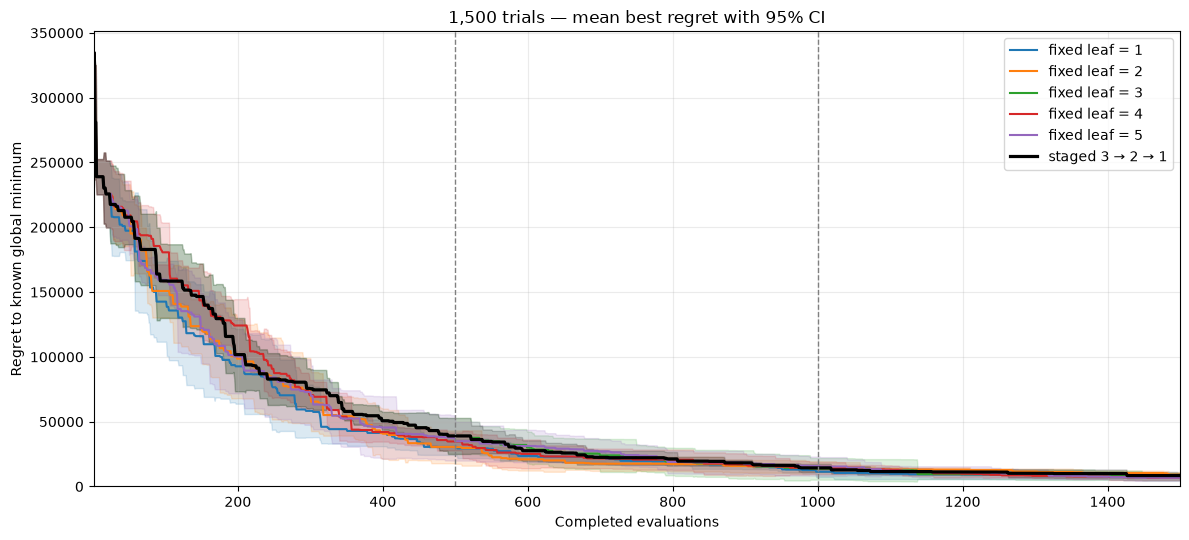

In [3]:
rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        rows.extend(
            {"policy": policy, "smac_seed": seed, "iteration": i, "best_regret": regret}
            for i, regret in zip(result["iteration"], result["best_regret"])
        )
trajectories = pd.DataFrame(rows)
summary = (
    trajectories.groupby(["policy", "iteration"])["best_regret"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary["ci95"] = 1.96 * summary["std"].fillna(0) / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(12, 5.5))
for policy in POLICIES:
    data = summary[summary["policy"] == policy]
    x, mean, ci = data["iteration"].to_numpy(), data["mean"].to_numpy(), data["ci95"].to_numpy()
    style = {"color": "black", "linewidth": 2.3} if policy == "staged_leaf_3_2_1" else {}
    line = ax.plot(x, mean, label=LABELS[policy], **style)[0]
    ax.fill_between(x, np.maximum(0, mean - ci), mean + ci, color=line.get_color(), alpha=0.16)
ax.axvline(500, color="grey", linestyle="--", linewidth=1)
ax.axvline(1000, color="grey", linestyle="--", linewidth=1)
ax.set(title="1,500 trials — mean best regret with 95% CI", xlabel="Completed evaluations", ylabel="Regret to known global minimum", xlim=(1, N_TRIALS))
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

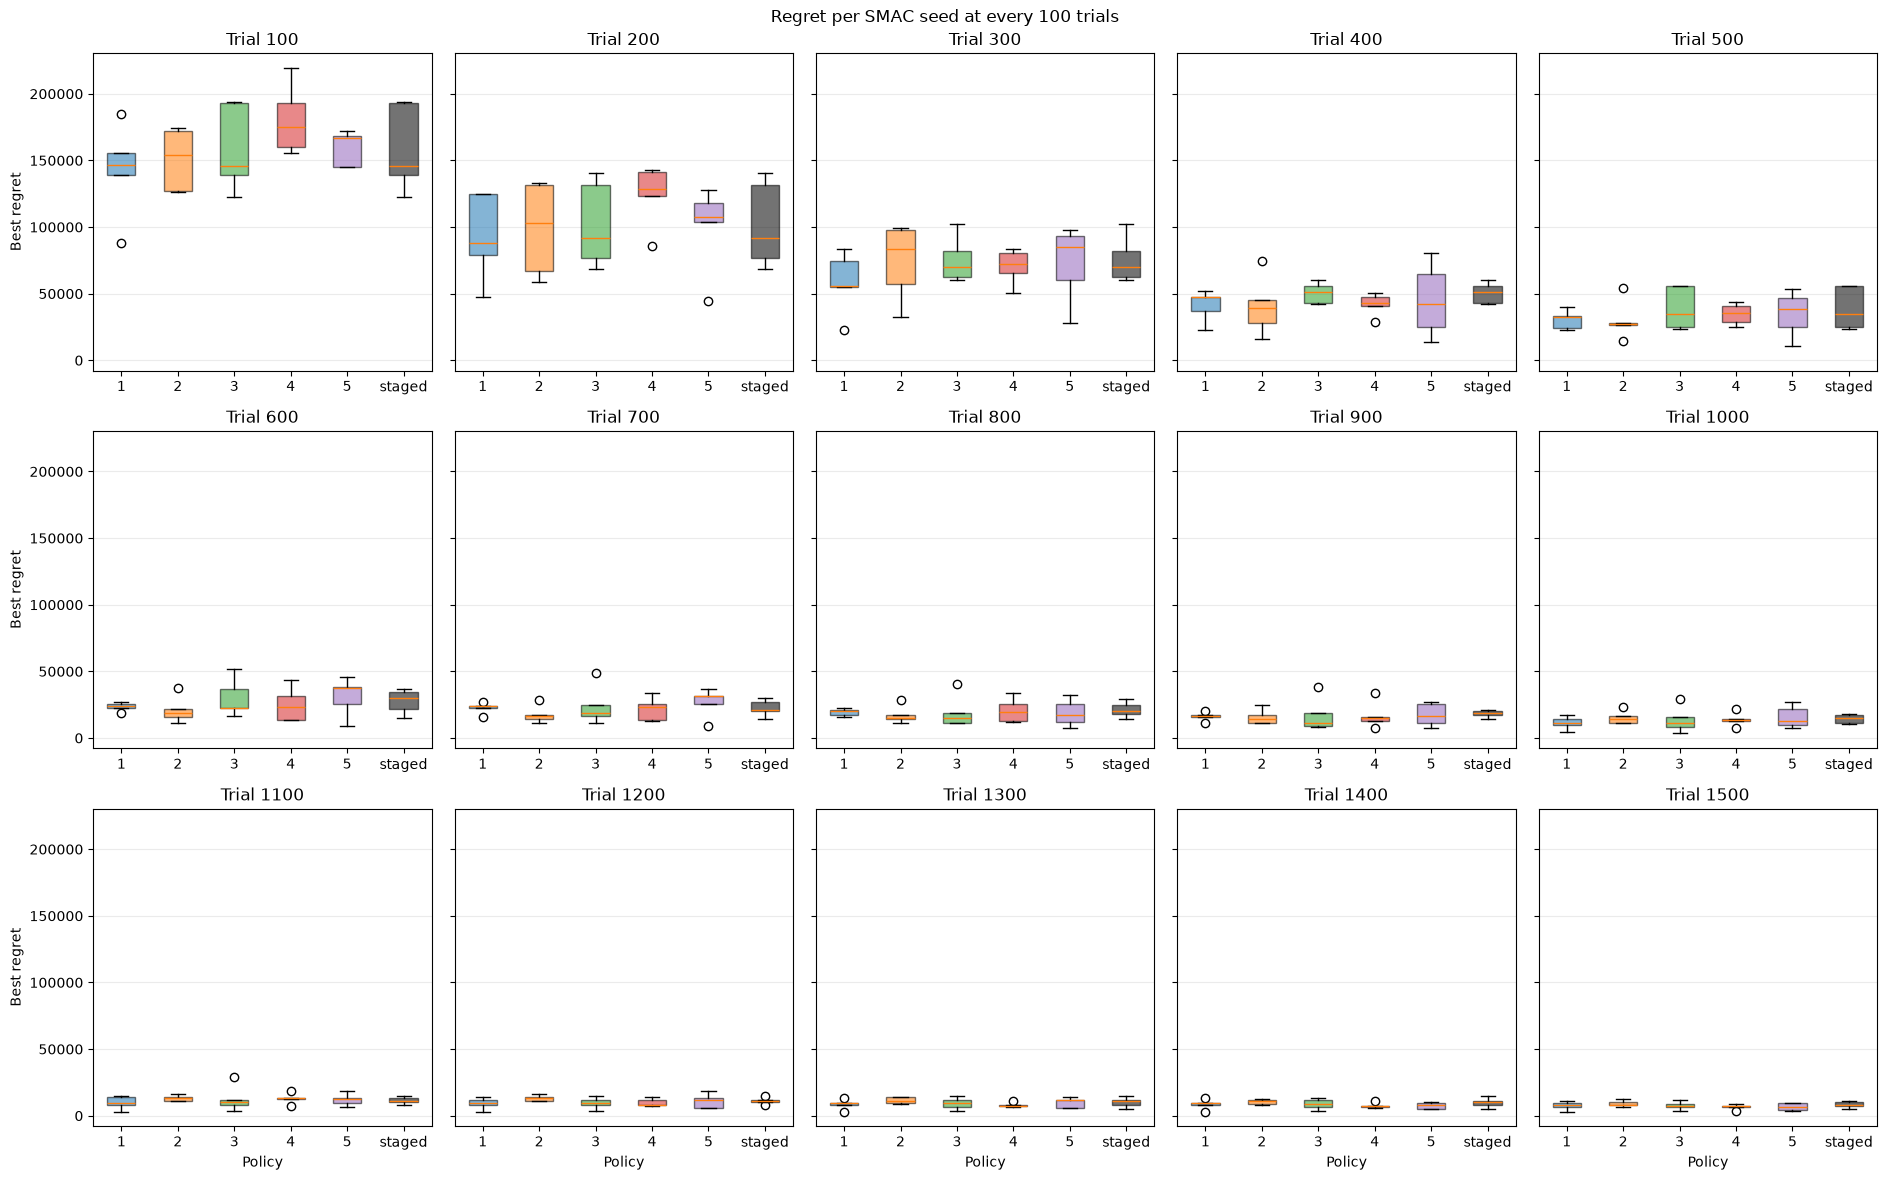

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(19, 12), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [
        [results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS]
        for policy in POLICIES
    ]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=["1", "2", "3", "4", "5", "staged"])
    for box, color in zip(boxes["boxes"], ("C0", "C1", "C2", "C3", "C4", "black")):
        box.set(facecolor=color, alpha=0.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.grid(axis="y", alpha=0.25)
for ax in axes[:, 0]:
    ax.set_ylabel("Best regret")
for ax in axes[-1, :]:
    ax.set_xlabel("Policy")
fig.suptitle("Regret per SMAC seed at every 100 trials")
plt.tight_layout()
plt.show()

In [5]:
(
    trajectories[trajectories["iteration"].isin(CHECKPOINTS)]
    .groupby(["iteration", "policy"])["best_regret"]
    .agg(["mean", "std", "min", "median", "max"])
)

mean           std            min  \
iteration policy                                                          
100       fixed_leaf_1       142621.541849  35261.099698   87811.357557   
          fixed_leaf_2       150856.163602  23406.704156  125970.005573   
          fixed_leaf_3       158637.343545  32675.682861  122396.626967   
          fixed_leaf_4       180677.418459  26167.048680  155884.418340   
          fixed_leaf_5       159522.530309  13506.015731  144743.992382   
...                                    ...           ...            ...   
1500      fixed_leaf_2         9151.850761   2361.706557    6789.445933   
          fixed_leaf_3         7607.201927   3298.091981    3259.877063   
          fixed_leaf_4         6629.325975   1963.322258    3326.490138   
          fixed_leaf_5         6742.302436   2737.894399    3783.059811   
          staged_leaf_3_2_1    8422.679535   2434.662343    5260.685575   

                                    median            max  
iteration policy                                           
100       fixed_leaf_1       146336.237076  184789.897988  
          fixed_leaf_2       154387.791183  174282.977316  
          fixed_leaf_3       145549.687757  193579.225852  
          fixed_leaf_4       175377.106587  219523.726894  
          fixed_leaf_5       167040.819179  172278.196016  
...                                    ...            ...  
1500      fixed_leaf_2         7960.333129   12546.576822  
          fixed_leaf_3         7370.922931   12109.908027  
          fixed_leaf_4         7296.487091    8427.795540  
          fixed_leaf_5         6633.751319    9640.552494  
          staged_leaf_3_2_1    7757.246444   11219.772387  

[90 rows x 5 columns]

## Number of trials at which each policy was best

Policies are compared at each trial by mean best regret across the five SMAC seeds. Every policy tied for the lowest mean regret receives credit.

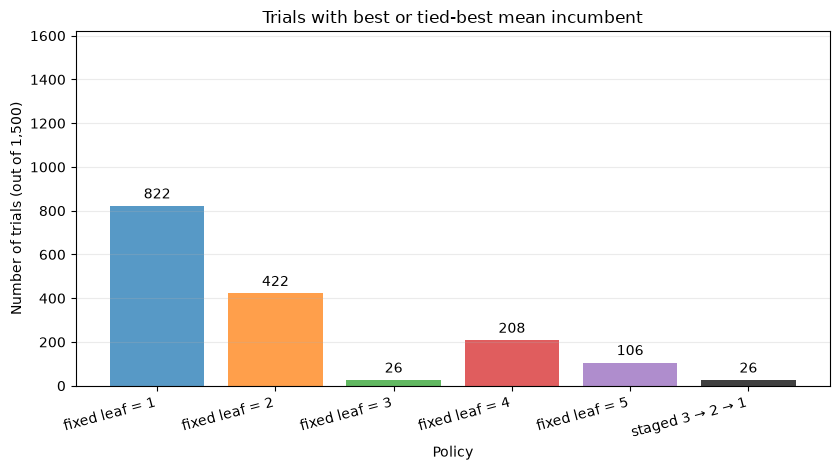

fixed_leaf_1         822
fixed_leaf_2         422
fixed_leaf_3          26
fixed_leaf_4         208
fixed_leaf_5         106
staged_leaf_3_2_1     26
dtype: int64

In [6]:
mean_regret = trajectories.pivot_table(
    index="iteration",
    columns="policy",
    values="best_regret",
    aggfunc="mean",
)
best_at_iteration = mean_regret.min(axis=1)
is_best_or_tied = pd.DataFrame(
    {
        policy: np.isclose(
            mean_regret[policy], best_at_iteration, rtol=1e-12, atol=1e-9
        )
        for policy in POLICIES
    },
    index=mean_regret.index,
)
best_counts = is_best_or_tied.sum().reindex(POLICIES)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    [LABELS[policy] for policy in POLICIES],
    best_counts.to_numpy(),
    color=("C0", "C1", "C2", "C3", "C4", "black"),
    alpha=0.75,
)
ax.bar_label(bars, padding=3)
ax.set(
    title="Trials with best or tied-best mean incumbent",
    xlabel="Policy",
    ylabel="Number of trials (out of 1,500)",
    ylim=(0, N_TRIALS * 1.08),
)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

best_counts

## Number of final 300 trials at which each policy was best

This repeats the comparison above using only iterations 1,201 through 1,500. Every policy tied for the lowest mean regret receives credit.

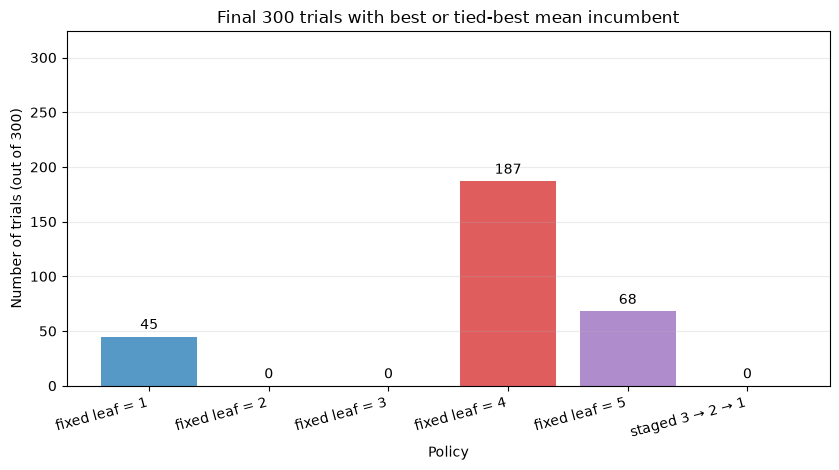

fixed_leaf_1          45
fixed_leaf_2           0
fixed_leaf_3           0
fixed_leaf_4         187
fixed_leaf_5          68
staged_leaf_3_2_1      0
dtype: int64

In [7]:
FINAL_WINDOW = 300
final_trajectories = trajectories[
    trajectories["iteration"] > N_TRIALS - FINAL_WINDOW
]
final_mean_regret = final_trajectories.pivot_table(
    index="iteration",
    columns="policy",
    values="best_regret",
    aggfunc="mean",
)
final_best_at_iteration = final_mean_regret.min(axis=1)
final_is_best_or_tied = pd.DataFrame(
    {
        policy: np.isclose(
            final_mean_regret[policy],
            final_best_at_iteration,
            rtol=1e-12,
            atol=1e-9,
        )
        for policy in POLICIES
    },
    index=final_mean_regret.index,
)
final_best_counts = final_is_best_or_tied.sum().reindex(POLICIES)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    [LABELS[policy] for policy in POLICIES],
    final_best_counts.to_numpy(),
    color=("C0", "C1", "C2", "C3", "C4", "black"),
    alpha=0.75,
)
ax.bar_label(bars, padding=3)
ax.set(
    title="Final 300 trials with best or tied-best mean incumbent",
    xlabel="Policy",
    ylabel="Number of trials (out of 300)",
    ylim=(0, FINAL_WINDOW * 1.08),
)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

final_best_counts